# Trade Dependence, Economic Stability, and Democracy
## A Panel Data Analysis (1980–2024)

### Research Questions
1. How has trade dependence evolved over time?
2. Does trade dependence affect economic stability? 
3. Is a higher democratic indicator associated with lower macroeconomic volatility?

---

### Motivation

Globalization has increased dramatically over the past 40 years. 
However, the relationship between trade integration and macroeconomic stability remains debated.

Major arguments:
- Integrating into global supply chains fosters economic stability by reducing reliance on domestic factors and diversifying risk.
- Integrating economies into global supply chains increases their vulnerability to external shocks, as it tethers domestic stability to the unpredictable fluctuations of international markets.

---

##### This notebook investigates the empirical relationship between Trade dependence, GDP volatility and Inflation volatility, and further studies if there is an actual correlation between Democratic institutions and overall economic stability.


<br> <br>

### Data Sources

This analysis uses annual country-level data from:

- World Bank World Development Indicators:
  - GDP Growth (% annual)
  - Inflation (Consumer Prices, Annual)
  - Imports (% of GDP)
  - Exports (% of GDP)
  - Merchandise Trade (% of GDP)

- EIU Democracy Index:
  - Democracy Index (0–10 scale)


### Dataset Description

#### World Bank – World Development Indicators (WDI)

The World Development Indicators (WDI), compiled by the World Bank, provide annual country-level macroeconomic data.

The following indicators are used:

1. **GDP Growth (annual %)**-
Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

2. **Inflation (Consumer Prices, annual %)**-
Inflation as measured by the consumer price index reflects the annual percentage change in the cost to the average consumer of acquiring a basket of goods and services that may be fixed or changed at specified intervals, such as yearly. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

3. **Exports of Goods and Services (% of GDP)** - 
Exports of goods includes changes in the economic ownership of goods from residents of the compiling economy to non-residents, irrespective of physical movement of goods across national borders. Exports of services includes services provided by residents to non-residents. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

4. **Imports of Goods and Services (% of GDP)**-
Imports of goods includes change in the economic ownership of goods from non-residents to residents of the compiling economy, irrespective of physical movement of goods across national borders. Imports of services includes services provided by non-residents to residents. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

5. **Merchandise Trade (% of GDP)** -
General merchandise trade includes goods whose economic ownership is changed between a resident and a non-resident and that are not included in the following specific categories: goods under merchanting, non-monetary gold, and parts of travel, construction, and government goods and services .i.e. It is the total of merchandise exports plus merchandise imports. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.


#### Economist Intelligence Unit – Democracy Index
Data by the Economist Intelligence Unit. Expert estimates of the extent to which citizens can choose their political leaders infree and fair elections, enjoy civil liberties, prefer democracy over other political systems, can and do participate in politics, andhave a functioning government that acts on their behalf. The index ranges from 0 to 10 (most democratic).


#### Time Period
+ 1980 - 2024 (for economic data)
+ 2000 - 2004 (for democratic index)

#### Sample
- Countries with valid ISO-3 codes and available data.
- Countries with missing data due to certain political instabilities have not been dropped if their data is available in the post 2000 period. 
- Countries without valid data on the year 2000 are dropped assuming unavailability of data due to several factors.


<br> <br>

##### Importing relevant python libraries for our analysis

In [2]:
# Importing relevant libraries
import pandas as pd
import pycountry

##### Creating certain functions to assist data loading, data cleaning, dataframe melting, and the panel dataframe creation process 

In [8]:
#Function to load dataset into a pandas dataframe and clean metadata in the process
def data_loader (data_path, n):
    """
    Takes the path of the raw data csv file and loads it into a pandas dataframe, clearing metadata if required
    Takes two arguments - The data path for the csv file and the number of rows comprising metadata
    """
    dataframe = pd.read_csv(data_path, skiprows=n)
    return dataframe




# Function to clean World Bank data
def wb_data_cleaner(raw_data):
    """
    Takes the world bank raw data and processes it
    Takes only the raw data as argument
    """
    
    #dropping the columns not relevant for our analysis
    raw_data = raw_data.drop(
        columns=["Indicator Name", "Indicator Code", "Unnamed: 69"]) 
    # removing aggregates
    iso_codes = [country.alpha_3 for country in pycountry.countries]
    clean_data = raw_data[raw_data["Country Code"].isin(iso_codes)]
    # deleting unwanted columns, ie 1960 to 80
    years_to_remove = [str(year) for year in range(1960, 1980)]
    clean_data = clean_data.drop(columns=years_to_remove)
    # dropping countries whose data is missing in 2000 (mention in methodology)
    clean_data = clean_data.dropna(subset=["2000"])
    # reseting index
    clean_data = clean_data.reset_index(drop=True)
    return clean_data



# Function to clean EIU Democracy data
def eiu_data_cleaner(raw_data):
    '''
    Takes the EIU data and processes it in a relevant manner. 
    Takes only the raw data as argument.
    '''
    # dropping columns not relevant for our analysis
    raw_data = raw_data[["REF_AREA", "TIME_PERIOD","OBS_VALUE", "REF_AREA_LABEL"]]
    #renaming columns for our analysis
    raw_data = raw_data.rename(columns={'REF_AREA': 'Country Code', 'TIME_PERIOD': 'Year', 'OBS_VALUE': 'Democracy Index', 'REF_AREA_LABEL': 'Country Name'})
    raw_data["Year"] = raw_data["Year"].astype(int)
    #rearranging columns
    raw_data = raw_data[['Country Name', 'Country Code', 'Year', 'Democracy Index']]

    iso_codes = [country.alpha_3 for country in pycountry.countries]
    clean_data = raw_data[raw_data["Country Code"].isin(iso_codes)]
    clean_data = clean_data.reset_index(drop = True)
    
    return clean_data



# Function to convert world bank's wide format data into a long format one
def data_metler(wide_data, data_subject):
    '''
    Takes the processed dataframe in wide table format and converts it into long format
    Takes two arguments, the wide data and the specific value contained in the data
    '''
    long_data = wide_data.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="Year",
        value_name=data_subject
    )
    long_data["Year"] = long_data["Year"].astype(int)
    return long_data



#Function to merge datasets and create a panel
def panel_creator(dataset1, dataset2, dataset3, dataset4, dataset5, dataset6):
    '''
    Takes the datasets (six for the purpose of this analysis) and merges them into a panel dataframe
    Takes the datasets to be merged as arguments
    '''
    merge_point = ["Country Name", "Country Code", "Year"]
    panel_df = dataset1.merge(dataset2, on = merge_point, how = "outer")
    panel_df = panel_df.merge(dataset3, on=merge_point, how="outer")
    panel_df = panel_df.merge(dataset4, on= merge_point, how="outer")
    panel_df = panel_df.merge(dataset5, on=merge_point, how="outer")
    #Casting the year as int for a smooth merge
    panel_df["Year"] = panel_df["Year"].astype(int) 
    panel_df = panel_df.merge(dataset6, on = merge_point, how="outer")
    #Sorting the data
    panel_df = panel_df.sort_values(["Country Code", "Year"])
    panel_df = panel_df.reset_index(drop = True)
    return panel_df
###explore reduce, lambda functions from the functools library

##### Loading the data from sources mentioned above

In [9]:

#Assigning variables to data paths
gdp_data_path = "./data/raw/gdp_annual.csv"
inflation_data_path = "./data/raw/inflation_cp_a.csv"
imports_data_path = "./data/raw/imports_gs.csv"
exports_data_path = "./data/raw/exports_gs.csv"
merchandise_trade_data_path = "./data/raw/merchandise_trade_gdp.csv"
democracy_index_data_path = "./data/raw/EIU_DI.csv"


#Loading into pandas dataframes, devoid of metadata
gdp_data = data_loader(gdp_data_path, 4)
inflation_data = data_loader(inflation_data_path, 4)
imports_data = data_loader(imports_data_path, 4)
exports_data = data_loader(exports_data_path, 4)
merchandise_trade_data = data_loader(merchandise_trade_data_path, 4)
democracy_index_data = data_loader(democracy_index_data_path, 0)


<br><br>

## Preliminary Observations on Raw Data

The World Bank datasets are provided in **wide format**, with annual observations stored across columns. The first four rows contain metadata and are excluded from analysis. Several non-analytical columns and regional or income-group aggregates are also present and must be removed. The data will require reshaping to long format to enable panel construction.

The Economist Intelligence Unit (EIU) Democracy Index dataset is structured in **long format**, but includes multiple fields beyond the scope of this study. Only the country-year identifiers and overall Democracy Index score will be retained.

Both sources contain regional aggregates and income classifications alongside sovereign countries. For consistency, only sovereign countries will be included, identified using standardized **ISO-3 country codes**.

### Preprocessing Steps

- Removal of metadata and redundant columns  
- Exclusion of non-country aggregates  
- Reshaping wide-format data to long format  
- Harmonization of country identifiers and year variables  
- Merging datasets into a unified country-year panel  

The final output will be a consolidated **country-year panel dataset**, suitable for time-series and econometric analysis.


<br> <br>

##### Cleaning and processing the data using the created functions

In [10]:
#Cleaning the data as required using specific functions for WB and EIU data
gdp_data = wb_data_cleaner(gdp_data)
inflation_data = wb_data_cleaner(inflation_data)
imports_data = wb_data_cleaner(imports_data)
exports_data = wb_data_cleaner(exports_data)
merchandise_trade_data = wb_data_cleaner(merchandise_trade_data)
democracy_index_data = eiu_data_cleaner(democracy_index_data)


#Melting the WB dataframes into long form
gdp_data = data_metler(gdp_data, "GDP Growth")
inflation_data = data_metler(inflation_data, "Inflation annual")
imports_data = data_metler(imports_data, "Imports per GDP")
exports_data = data_metler(exports_data, "Exports per GDP")
merchandise_trade_data = data_metler(merchandise_trade_data, "Merchadise Trade per GDP")
#The EIU data is already in long format

##### Merging the various dataframes into a single sorted - panel dataset

In [12]:
panel_dataframe = panel_creator(gdp_data, inflation_data, imports_data, exports_data, merchandise_trade_data, democracy_index_data)
panel_dataframe

,Country Name,Country Code,Year,GDP Growth,Inflation annual,Imports per GDP,Exports per GDP,Merchadise Trade per GDP,Democracy Index
0,Aruba,ABW,1980,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1981,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1982,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,1983,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,1984,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9119,Zimbabwe,ZWE,2020,-7.816951,NaN,21.247181,18.931225,31.388039,3.16
9120,Zimbabwe,ZWE,2021,8.468017,NaN,24.354942,19.759617,32.971100,2.92
9121,Zimbabwe,ZWE,2022,6.139263,NaN,31.368133,23.699220,37.389381,2.92
9122,Zimbabwe,ZWE,2023,5.350869,NaN,23.174185,17.117076,45.827110,3.04


## Methodology

This study employs a country-year panel framework to examine the relationship between trade openness, democratic institutions, and macroeconomic stability.

### 1. Trade Dependence

Trade dependence (openness) is defined as the sum of exports and imports as a percentage of GDP:

$$
\text{Trade Dependence}_{it} = \frac{\text{Exports}_{it} + \text{Imports}_{it}}{\text{GDP}_{it}}
$$

Where:
* $i$ denotes the country.
* $t$ denotes the year.

This measure captures the extent to which a country’s economy is integrated into global trade relative to the size of its domestic output. Higher values indicate greater exposure to international trade.

---

### 2. Economic Stability (Volatility Measures)

Macroeconomic instability is proxied using rolling volatility measures computed over a five-year window.

#### GDP Volatility (5-year)

This represents the rolling standard deviation of annual GDP growth over the previous five years:

$$
\text{GDP Volatility}_{it} = \sigma(\text{GDP Growth}_{i, t-4 \dots t})
$$

The rolling window smooths short-term fluctuations while capturing medium-term macroeconomic instability.

#### Inflation Volatility (5-year)

Similarly, inflation volatility is calculated as the rolling standard deviation of annual inflation rates over a five-year period:

$$
\text{Inflation Volatility}_{it} = \sigma(\text{Inflation}_{i, t-4 \dots t})
$$

A five-year window is chosen to balance responsiveness to economic shocks with stability in volatility estimation.

---

### 3. Democracy

Institutional quality is measured using the **Democracy Index** (0–10 scale), where higher values indicate stronger democratic institutions.

Democracy is included to assess whether institutional structures are associated with reduced macroeconomic volatility.

---

### 4. Empirical Strategy

The analysis proceeds in three stages:

1.  **Descriptive Analysis:** Examining trade openness trends over time.
2.  **Correlation Analysis:** Assessing the linear relationship between trade dependence and volatility measures.
3.  **Regression Analysis:** Examining the joint relationship between trade openness, democracy, and macroeconomic instability.

All computations are conducted using country-level annual data within a balanced country-year panel where data availability permits.

<br> <br> <br>

#### Creating relevant variables, calculating Trade Dependence, Economic Instability and Inflation Volatility

In [16]:
#Creating trade dependence/openness variable
panel_dataframe["Trade Dependence"] = (
    panel_dataframe["Imports per GDP"] + panel_dataframe["Exports per GDP"]
)

#Economic Instability = volatility of GDP Growth 

panel_dataframe["GDP Volatility (5y)"] = (
    panel_dataframe
    .groupby("Country Code")["GDP Growth"]
    .rolling(window = 5)
    .std()
    .reset_index(level=0, drop = True)
)

# Inflation volatility - unstable economies have volatile inflation

panel_dataframe["Inflation Volatility (5y)"] = (
    panel_dataframe.groupby("Country Code")["Inflation annual"]
    .rolling(window = 5)
    .std()
    .reset_index(level= 0, drop=True)
        
)
panel_dataframe

,Country Name,Country Code,Year,GDP Growth,Inflation annual,Imports per GDP,Exports per GDP,Merchadise Trade per GDP,Democracy Index,Trade Dependence,GDP Volatility (5y),Inflation Volatility (5y)
0,Aruba,ABW,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aruba,ABW,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aruba,ABW,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9119,Zimbabwe,ZWE,2020,-7.816951,NaN,21.247181,18.931225,31.388039,3.16,40.178406,6.054469,NaN
9120,Zimbabwe,ZWE,2021,8.468017,NaN,24.354942,19.759617,32.971100,2.92,44.114559,7.367571,NaN
9121,Zimbabwe,ZWE,2022,6.139263,NaN,31.368133,23.699220,37.389381,2.92,55.067352,7.578299,NaN
9122,Zimbabwe,ZWE,2023,5.350869,NaN,23.174185,17.117076,45.827110,3.04,40.291261,7.623746,NaN


<br> <br>

###  Descriptive Analysis: Trade Dependence Trends

<Axes: title={'center': 'Average Trade Dependence Over Time'}, xlabel='Year', ylabel='Trade Dependence (% of GDP)'>

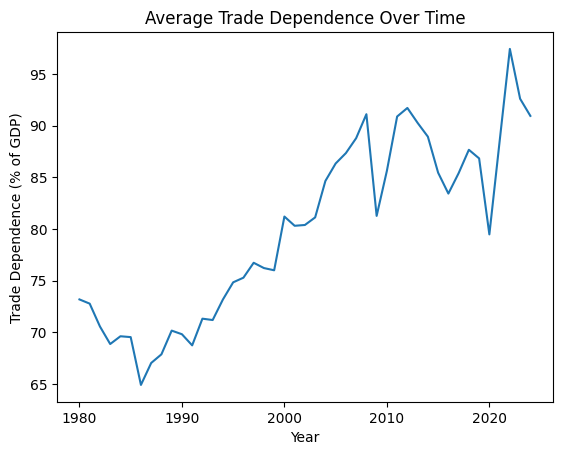

In [19]:
trade_trend = (
    panel_dataframe
    .groupby("Year")["Trade Dependence"]
    .mean()
)

trade_trend.plot(
    xlabel="Year",
    ylabel="Trade Dependence (% of GDP)",
    title="Average Trade Dependence Over Time"
    )

*Figure 1: Evolution of Trade Dependence (1980–2024)*

The time-series plot above illustrates the evolution of **Trade Dependence** over the sample period 1980–2024. Several distinct phases and structural breaks are evident, which are relevant to the study of macroeconomic stability.

### A. The Era of Hyper-Globalization (1986–2008)
From a local minimum in roughly 1986 (approx. 65%), the data shows a robust and nearly monotonic upward trend for two decades.
* **Observation:** This period is characterized by low volatility in trade openness, reflecting the steady integration of the economy into global markets (often associated with the "Great Moderation").
* **Peak:** This phase culminates in a local peak in 2008, reaching approximately 91% trade dependence.

### B. The 2008 Financial Crisis Shock
A sharp structural break occurs in 2008/2009, corresponding to the Global Financial Crisis.
* **Impact:** Trade dependence plummets from ~91% to ~81% in a single year, demonstrating how external shocks can rapidly transmit through trade channels.

### C. The "Slowbalization" and Volatility Phase (2010–2019)
Post-2010, the trend differs significantly from the pre-2008 era.
* **Volatility:** Instead of a steady rise, the index exhibits significant variance, oscillating between 83% and 92%.
* **Stagnation:** There is no clear secular upward trend during this decade, suggesting a period of stagnation in trade integration often referred to as "slowbalization."

### D. The Pandemic Shock and Recovery (2020–Present)
The most dramatic volatility occurs at the end of the sample:
* **The 2020 Crash:** A massive contraction is visible in 2020 (likely COVID-19 induced), where trade dependence drops sharply to near 80%.
* **The Rebound:** This is followed by an immediate, steep V-shaped recovery, driving trade dependence to an **all-time high of nearly 98% in roughly 2022**, before a slight correction in the final observations.

**Conclusion:** The graph highlights that Trade Dependence is not static. The significant increase in volatility post-2008 validates the need to use rolling volatility measures rather than simple averages to capture these dynamic risks.